In [1]:
import pandas as pd

# Load pH measurements dataset with the correct separator
ph_data = pd.read_csv('../data/pH.csv', sep=';')

# Load metadata for monitoring stations
station_metadata = pd.read_csv('../data/GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

# Load metadata describing each measured parameter
parameter_info = pd.read_csv('../data/GEMStat_parameter_metadata.csv', sep=';', encoding='ISO-8859-1')

# Load metadata on measurement methods
methods_info = pd.read_csv('../data/GEMStat_methods_metadata.csv', sep=';', encoding='ISO-8859-1')

# Check columns
print(ph_data.columns.tolist())
print(station_metadata.columns.tolist())


C:\Users\celia\AppData\Local\Temp\ipykernel_16900\1263375728.py:4: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  ph_data = pd.read_csv('../data/pH.csv', sep=';')


['GEMS.Station.Number', 'Sample.Date', 'Sample.Time', 'Depth', 'Parameter.Code', 'Analysis.Method.Code', 'Value.Flags', 'Value', 'Unit', 'Data.Quality']
['GEMS Station Number', 'Local Station Number', 'Country Name', 'Water Type', 'Station Identifier', 'Station Narrative', 'Water Body Name', 'Main Basin', 'Upstream Basin Area', 'Elevation', 'Monitoring Type', 'Date Station Opened', 'Responsible Collection Agency', 'Latitude', 'Longitude', 'River Width', 'Discharge', 'Max. Depth', 'Lake Area', 'Lake Volume', 'Average Retention', 'Area of Aquifer', 'Depth of Impermeable Lining', 'Production Zone', 'Mean Abstraction Rate', 'Mean Abstraction Level']


In [2]:
# Fix the station column name to match 
station_metadata.rename(columns={'GEMS Station Number': 'GEMS.Station.Number'}, inplace=True)

# Merge pH data with station metadata based on 'GEMS.Station.Number'
merged = pd.merge(ph_data, station_metadata, how='left', on='GEMS.Station.Number')

# See first few rows
print(merged[['GEMS.Station.Number', 'Country Name', 'Latitude', 'Longitude', 'Value']].head())



  GEMS.Station.Number Country Name    Latitude   Longitude  Value
0            ARG00003    Argentina  -26,925888  -58,507027   7.75
1            ARG00003    Argentina  -26,925888  -58,507027   7.16
2            ARG00003    Argentina  -26,925888  -58,507027   7.56
3            ARG00003    Argentina  -26,925888  -58,507027   7.10
4            ARG00003    Argentina  -26,925888  -58,507027   7.47


In [3]:
# Show first few rows
print(merged[['Country Name', 'Sample.Date']].head())

# Show unique countries
print("\nUnique countries in data:")
print(merged['Country Name'].dropna().unique())

# Show year distribution (extract year from Sample.Date)
merged['Year'] = pd.to_datetime(merged['Sample.Date'], errors='coerce').dt.year
print("\nYears available in data:")
print(merged['Year'].dropna().unique())


  Country Name Sample.Date
0    Argentina  2018-08-22
1    Argentina  2018-11-15
2    Argentina  2019-02-21
3    Argentina  2019-05-08
4    Argentina  2019-11-06

Unique countries in data:
['Argentina' 'Austria' 'Belgium' 'Bulgaria' 'Bosnia and Herzegovina'
 'Canada' 'Switzerland' 'Denmark' 'Spain' 'Estonia' 'Finland' 'France'
 'Greece' 'Croatia' 'India' 'Ireland' 'Iceland' 'Italy' 'Lithuania'
 'Latvia' 'Mexico' 'Macedonia (the former Yugoslav Republic of)'
 'Netherlands (the)' 'Norway' 'Poland' 'Portugal' 'Romania' 'Serbia'
 'Slovenia' 'Sweden' 'Uruguay' 'United States of America (the)']

Years available in data:
[2018 2019 2020 2021 2022 2011 2012 2013 2023 2009 2010 2014 2017 2016
 2008 2015 2001 2002 2003 2004 2005 2006 2007 2000 1999 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1972 1969 1963 1964 1965
 1966 1967 1968 1970 1971]


c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


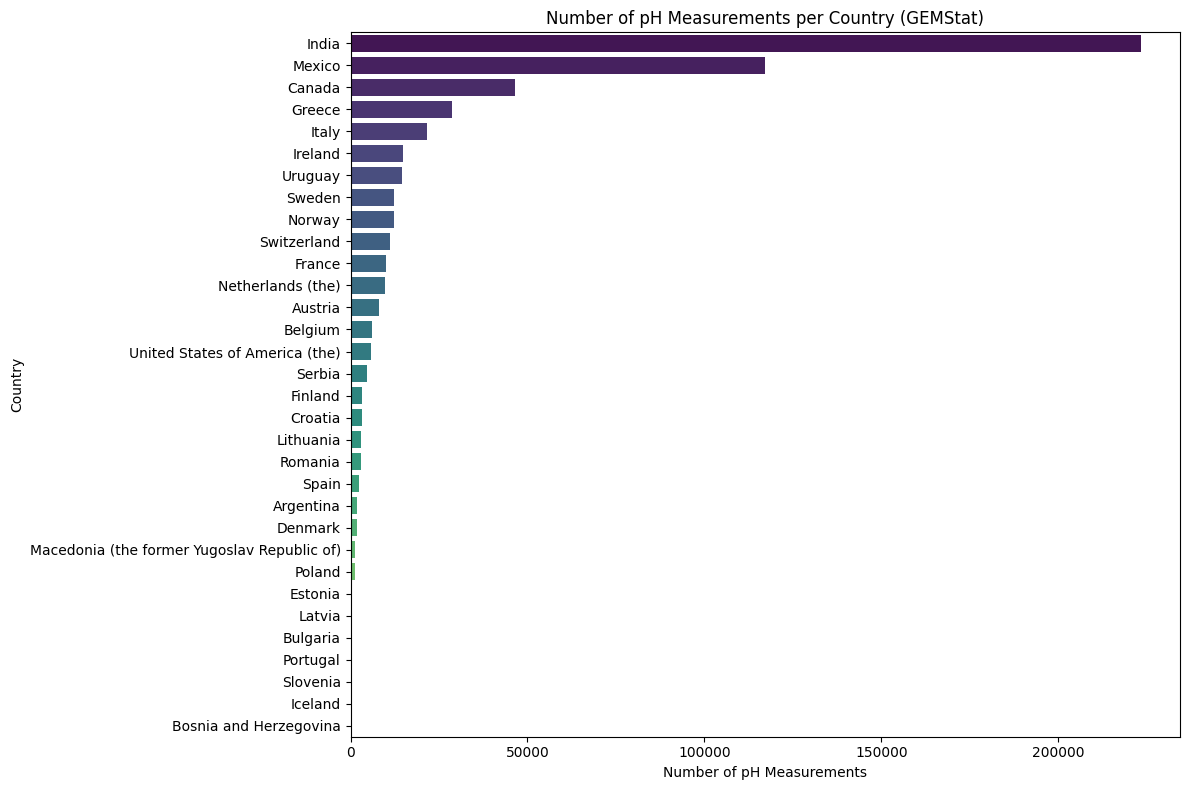

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of measurements per country
country_counts = merged['Country Name'].value_counts()

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=country_counts.values, y=country_counts.index, palette="viridis")
plt.xlabel("Number of pH Measurements")
plt.ylabel("Country")
plt.title("Number of pH Measurements per Country (GEMStat)")
plt.tight_layout()
plt.show()


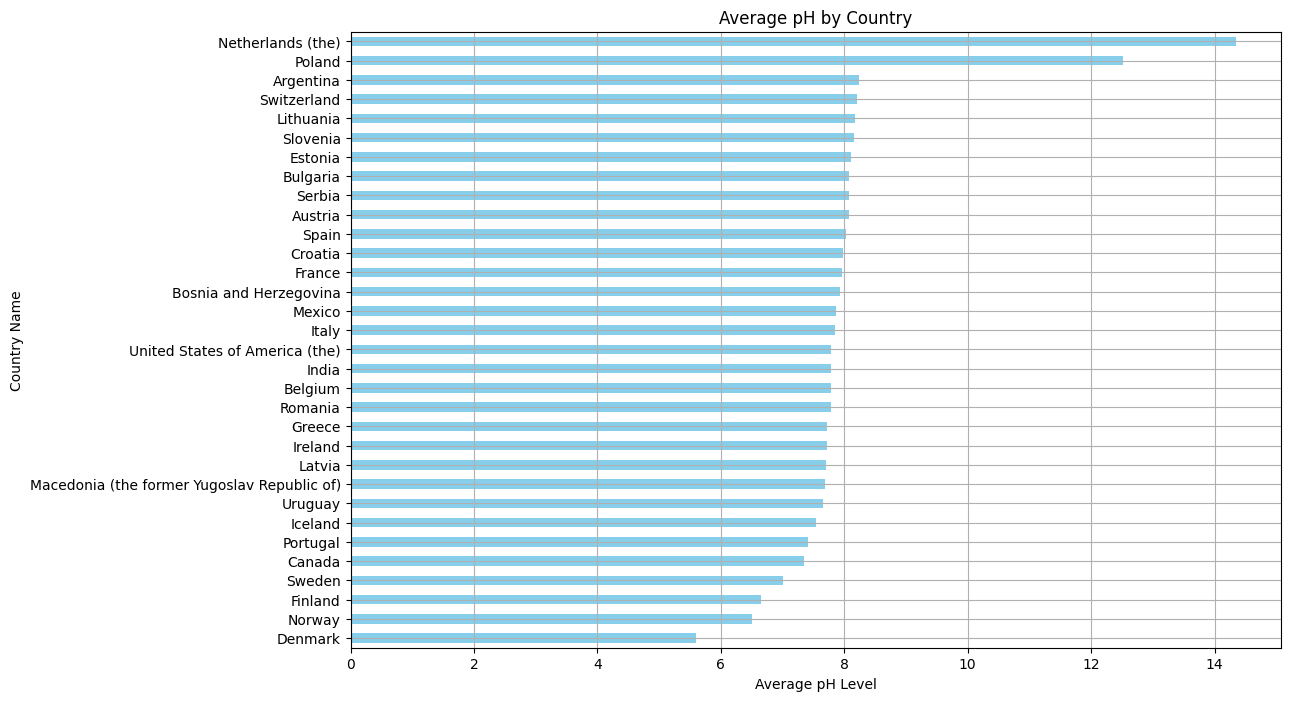

In [5]:
# Calculate the average pH value for each country
# Group data by 'Country Name' and compute the mean of the 'Value' column (which holds pH measurements)
avg_ph_country = merged.groupby('Country Name')['Value'].mean().sort_values()

# plot
plt.figure(figsize=(12,8))
avg_ph_country.plot(kind='barh', color='skyblue')
plt.xlabel('Average pH Level')
plt.title('Average pH by Country')
plt.grid(True)
plt.show()


In [6]:
# Only keep realistic pH values between 0 and 14
merged = merged[(merged['Value'] >= 0) & (merged['Value'] <= 14)]

#check
print(merged['Value'].describe())


count    569473.000000
mean          7.722133
std           0.691797
min           0.000000
25%           7.400000
50%           7.820000
75%           8.180000
max          13.660000
Name: Value, dtype: float64


C:\Users\celia\AppData\Local\Temp\ipykernel_16900\1722194947.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poland_trend['Year'] = pd.to_datetime(poland_trend['Sample.Date']).dt.year


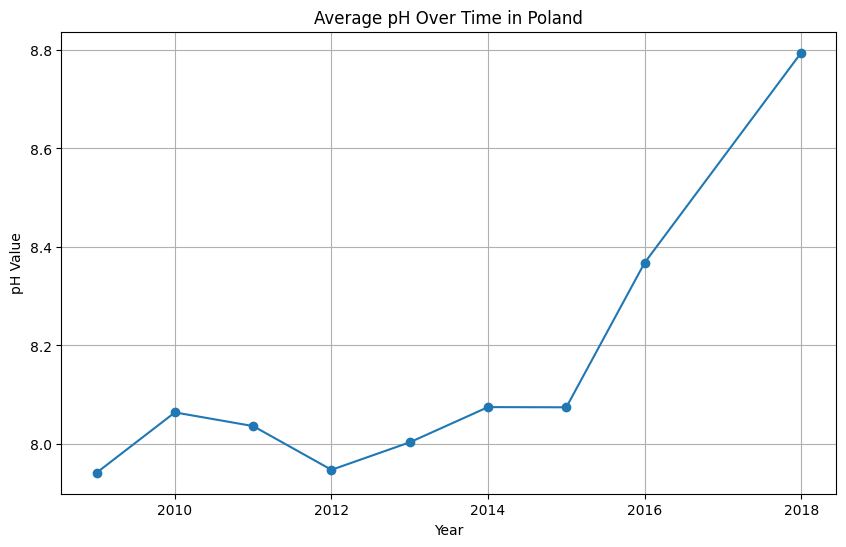

In [7]:
# Filter the dataset to include only records from Poland
poland_trend = merged[merged['Country Name'] == 'Poland']

# Extract the year from the 'Sample.Date' column 
# store it in a new 'Year' column to group the data by year
poland_trend['Year'] = pd.to_datetime(poland_trend['Sample.Date']).dt.year

# Calculate the average pH value for each year
avg_yearly_ph = poland_trend.groupby('Year')['Value'].mean()

# plot
plt.figure(figsize=(10,6))
avg_yearly_ph.plot(marker='o')
plt.title('Average pH Over Time in Poland')
plt.ylabel('pH Value')
plt.xlabel('Year')
plt.grid(True)
plt.show()


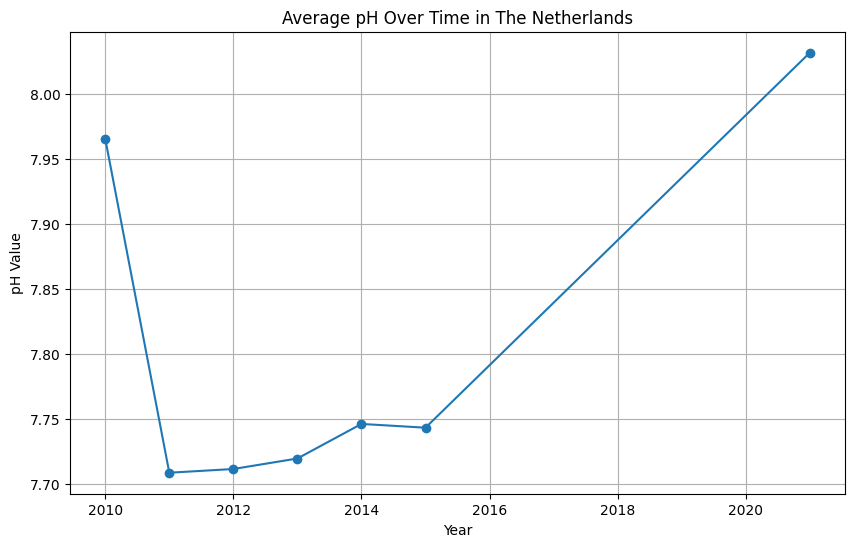

In [8]:
import matplotlib.pyplot as plt


# Filter the dataset to include only records from the Netherlands
netherlands_trend = merged[merged['Country Name'] == 'Netherlands (the)']

# Extract the year from the 'Sample.Date' column to analyze yearly trends
# Convert the date strings to datetime objects, extract the year into a new 'Year' column
netherlands_trend.loc[:, 'Year'] = pd.to_datetime(netherlands_trend['Sample.Date']).dt.year

# Calculate the average pH value for each year
# Group the data by year and compute the mean pH value for that year
avg_yearly_ph = netherlands_trend.groupby('Year')['Value'].mean()

# Create a line plot to show how pH levels have changed over time
plt.figure(figsize=(10,6))
avg_yearly_ph.plot(marker='o')
plt.title('Average pH Over Time in The Netherlands')
plt.ylabel('pH Value')
plt.xlabel('Year')
plt.grid(True)
plt.show()


C:\Users\celia\AppData\Local\Temp\ipykernel_16900\1178090828.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  denmark_trend['Year'] = pd.to_datetime(denmark_trend['Sample.Date']).dt.year


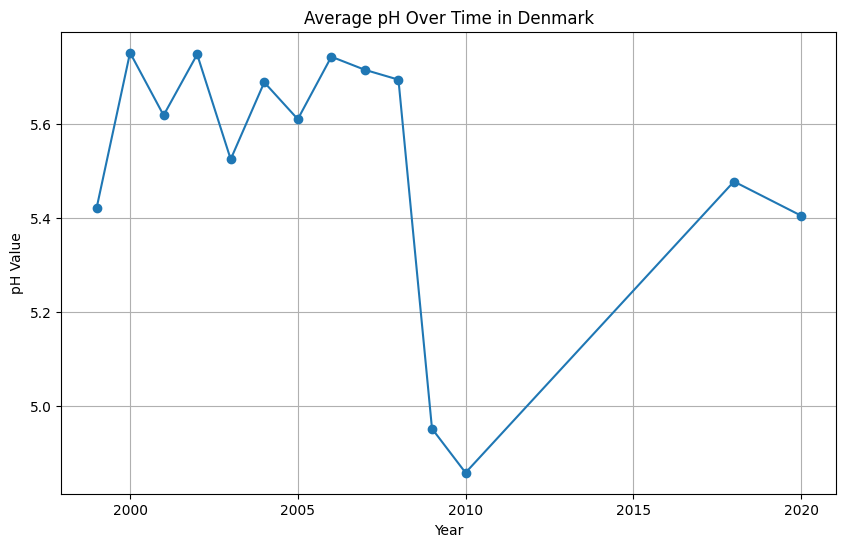

In [9]:
# Filter the dataset to include only records from Denmark
denmark_trend = merged[merged['Country Name'] == 'Denmark']

# Extract the year from the 'Sample.Date' column
# Convert date strings to datetime format and extract the year for grouping
denmark_trend['Year'] = pd.to_datetime(denmark_trend['Sample.Date']).dt.year

# Calculate the average pH value for each year
# Group the data by year and compute the mean pH level per year
avg_yearly_ph = denmark_trend.groupby('Year')['Value'].mean()

# Plot the average yearly pH values to visualize trends over time
plt.figure(figsize=(10,6))
avg_yearly_ph.plot(marker='o')
plt.title('Average pH Over Time in Denmark')
plt.ylabel('pH Value')
plt.xlabel('Year')
plt.grid(True)
plt.show()


C:\Users\celia\AppData\Local\Temp\ipykernel_16900\4168848069.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norway_trend['Year'] = pd.to_datetime(norway_trend['Sample.Date']).dt.year


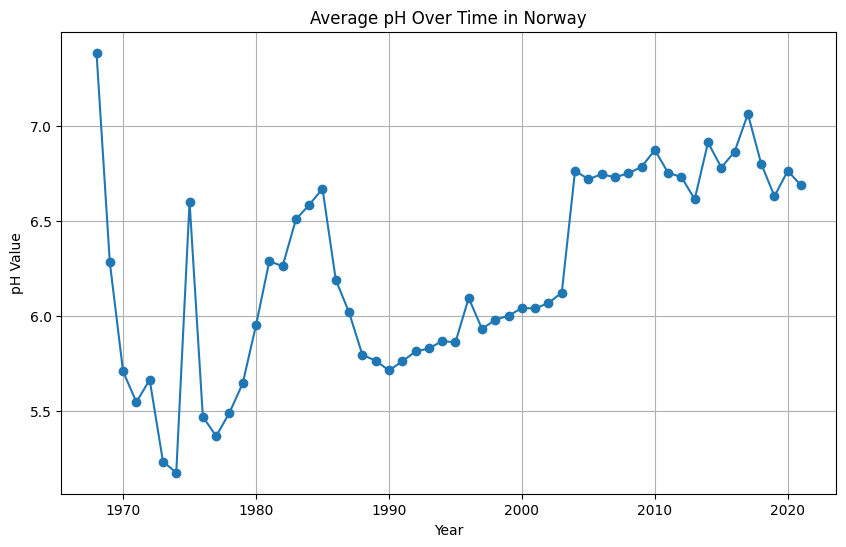

In [10]:
# Filter the dataset to include only records from Norway
norway_trend = merged[merged['Country Name'] == 'Norway']

# Extract the year from the 'Sample.Date' column
# Convert the date to datetime format and extract the year into a new 'Year' column
norway_trend['Year'] = pd.to_datetime(norway_trend['Sample.Date']).dt.year

# Calculate the average pH value for each year
# Group the data by year and compute the mean pH value for each group
avg_yearly_ph = norway_trend.groupby('Year')['Value'].mean()

# Plot the average pH trend over the years
plt.figure(figsize=(10,6))
avg_yearly_ph.plot(marker='o')
plt.title('Average pH Over Time in Norway')
plt.ylabel('pH Value')
plt.xlabel('Year')
plt.grid(True)
plt.show()


In [11]:
# Import Plotly Express for interactive visualizations
import plotly.express as px

# Group the merged dataset by country and calculate the mean pH value for each country
avg_ph_country = merged.groupby('Country Name')['Value'].mean().reset_index()

# Create an interactive choropleth map to visualize average pH by country
fig = px.choropleth(
    # Data source
    avg_ph_country,
    locations="Country Name",
    locationmode="country names",
    color="Value",
    color_continuous_scale="Viridis",
    title="Average pH by Country"
)

# Customize the appearance of the map projection and features
fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

# Display the interactive map 
fig.show()

# Save the map as an interactive HTML file 
fig.write_html("../visualizations/ph_map.html", include_plotlyjs='cdn')





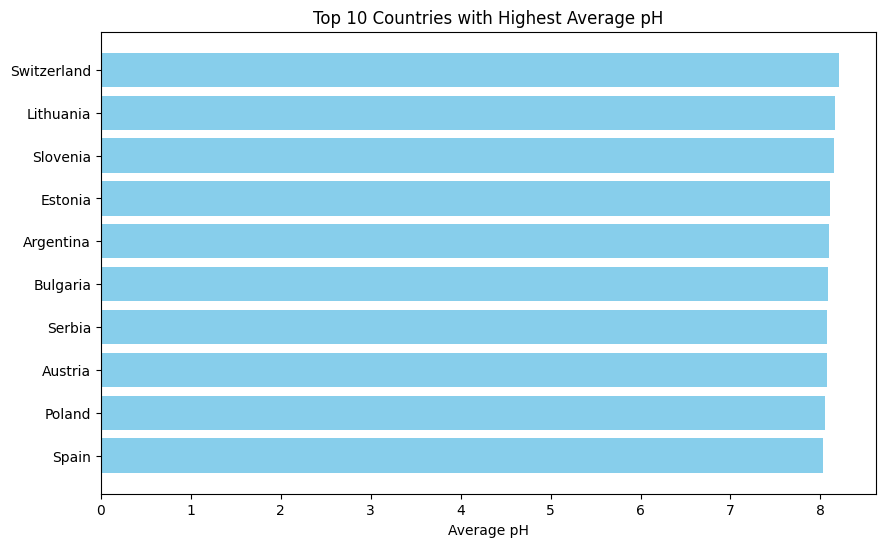

In [12]:
# Top 10 countries with highest pH
# Sort the countries in descending order of average pH and select the top 10
top10_ph = avg_ph_country.sort_values(by='Value', ascending=False).head(10)

# Create a horizontal bar plot to display the top 10 countries by average pH
plt.figure(figsize=(10,6))
plt.barh(top10_ph['Country Name'], top10_ph['Value'], color='skyblue')
plt.title('Top 10 Countries with Highest Average pH')
plt.xlabel('Average pH')
plt.gca().invert_yaxis()
plt.show()


In [13]:
# create csv for froggy
# redoing every step for merging just to be extra cautious (mostly copied from above or prior code from this notebook)

import pandas as pd

# Load pH measurements and station metadata from CSV files
ph_data = pd.read_csv('../data/pH.csv', sep=';', low_memory=False)
station_metadata = pd.read_csv('../data/GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

# Clean up column names by stripping extra whitespace
ph_data.columns = ph_data.columns.str.strip()
station_metadata.columns = station_metadata.columns.str.strip()

# Rename the station column in metadata to match the pH dataset for merging
station_metadata.rename(columns={'GEMS Station Number': 'GEMS.Station.Number'}, inplace=True)

# Merge the pH data with station metadata using the station number as the key
merged = pd.merge(ph_data, station_metadata, how='left', on='GEMS.Station.Number')

# Convert the 'Sample.Date' column to datetime format, coercing errors to NaT (missing)
merged['Sample.Date'] = pd.to_datetime(merged['Sample.Date'], errors='coerce')

# Extract the year from the parsed dates into a new 'Year' column
merged['Year'] = merged['Sample.Date'].dt.year

# Convert pH values to numeric, coercing errors to NaN 
merged['Value'] = pd.to_numeric(merged['Value'], errors='coerce')

# Filter out unrealistic pH values (valid environmental range is 0–14)
merged = merged[(merged['Value'] >= 0) & (merged['Value'] <= 14)]

# Group the cleaned data by country and year, calculating the mean pH for each group
ph_summary = merged.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()

# Rename columns for clarity
ph_summary.columns = ['Country', 'Year', 'Average pH']

# Define a function to classify pH levels into categories
def classify_ph(ph):
    if ph < 6.5:
        return "Acidic"
    elif ph > 8.5:
        return "Alkaline"
    else:
        return "Neutral (safe range)"

# Apply the classification to each average pH value
ph_summary['Notes'] = ph_summary['Average pH'].apply(classify_ph)

# Save to CSV
ph_summary.to_csv('../visualizations/ph_country_year_summary.csv', index=False)
